<a href="https://colab.research.google.com/github/imostafizur/tensorflow_board/blob/master/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Dataset download

In [2]:
import os

os.environ['KAGGLE_USERNAME'] = "imostafizur" # username from the json file
os.environ['KAGGLE_KEY'] = "209f4b70995998e465b2702534f7a5ff" # key from the json file

In [3]:
!kaggle datasets download ruchi798/movies-on-netflix-prime-video-hulu-and-disney

Dataset URL: https://www.kaggle.com/datasets/ruchi798/movies-on-netflix-prime-video-hulu-and-disney
License(s): CC0-1.0
  0% 0.00/166k [00:00<?, ?B/s]
100% 166k/166k [00:00<00:00, 335MB/s]


### Dataset view

In [4]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [5]:
# Path to your file in Colab
file_path = "/content/MoviesOnStreamingPlatforms.csv"

In [7]:
# Load the dataset
df = pd.read_csv(file_path)

In [8]:
# Show the first few rows
df.head()

,Unnamed: 0,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type
0,0,1,The Irishman,2019,18+,98/100,1,0,0,0,0
1,1,2,Dangal,2016,7+,97/100,1,0,0,0,0
2,2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,0
3,3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,0
4,4,5,Roma,2018,18+,94/100,1,0,0,0,0


In [9]:
df.columns

Index(['Unnamed: 0', 'ID', 'Title', 'Year', 'Age', 'Rotten Tomatoes',
       'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'Type'],
      dtype='object')

In [10]:
df = df.drop(columns=['Unnamed: 0'])

In [17]:
import pandas as pd
import numpy as np
import re, os

In [18]:
# --- Load dataset ---
file_path = "/content/MoviesOnStreamingPlatforms.csv"
assert os.path.exists(file_path), f"File not found: {file_path}"
df = pd.read_csv(file_path)
print("Initial shape:", df.shape)

Initial shape: (9515, 11)


In [19]:
# --- Drop useless columns ---
for c in ['Unnamed: 0', 'ID']:
    if c in df.columns:
        df = df.drop(columns=[c])

print("After dropping index/ID columns:", df.shape)

After dropping index/ID columns: (9515, 9)


#### Dataset cleaning

In [20]:
# =======================
# HANDLE TYPE COLUMN SAFELY
# =======================
filtered = False

if "Type" in df.columns:
    print("\nType column values:", df["Type"].value_counts(dropna=False).head(10))

    # Convert to string for safe checking
    type_str = df["Type"].astype(str).str.strip().str.lower()

    # Case 1: Text "movie"
    if "movie" in type_str.unique():
        df = df[type_str == "movie"].copy()
        print("Filtered rows where Type == 'Movie' (textual).")
        filtered = True

    else:
        # Case 2: Numeric 0/1
        type_num = pd.to_numeric(df["Type"], errors="coerce")
        uniq = sorted(type_num.dropna().unique().tolist())

        if set(uniq).issubset({0.0, 1.0}):
            # Your dataset sample shows 0 = Movie
            df = df[type_num == 0].copy()
            print("Filtered rows where Type == 0 (assumed Movie).")
            filtered = True
        else:
            print("Type column not in expected format. No filtering applied.")

print("After Type filtering:", df.shape)

# =======================
# CLEAN ROTTEN TOMATOES
# =======================
def parse_rt_robust(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s == "" or s.lower() in ("nan", "none", "n/a"):
        return np.nan

    # Formats like "98/100"
    m = re.search(r"^\s*(\d{1,3})\s*/\s*100\s*$", s)
    if m:
        return float(m.group(1))

    # Formats like "94%"
    m = re.search(r"^(\d{1,3})\s*%$", s)
    if m:
        return float(m.group(1))

    # Plain numbers
    m = re.search(r"(\d{1,3})", s)
    if m:
        return float(m.group(1))

    return np.nan

df["rt_score"] = df["Rotten Tomatoes"].apply(parse_rt_robust)
print("\nRT parsing complete. Example:")
print(df[["Rotten Tomatoes", "rt_score"]].head(8))

# =======================
# CLEAN AGE COLUMN
# =======================
def safe_age(age):
    if pd.isna(age):
        return np.nan
    s = str(age).strip().lower()
    mapping = {
        "all":0, "g":0,
        "pg":1, "7+":1, "7":1,
        "pg-13":2, "pg13":2, "13+":2, "13":2,
        "16+":3, "16":3, "tv-14":3,
        "r":4, "18+":4, "18":4, "tv-ma":4
    }
    if s in mapping:
        return mapping[s]
    # Extract digits
    m = re.search(r"(\d+)", s)
    if m:
        n = int(m.group(1))
        if n <= 7: return 1
        if n <= 13: return 2
        if n <= 16: return 3
        return 4
    return np.nan

df["age_code"] = df["Age"].apply(safe_age)

# =======================
# CLEAN YEAR COLUMN
# =======================
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# =======================
# CLEAN PLATFORM FLAGS
# =======================
for col in ["Netflix", "Hulu", "Prime Video", "Disney+"]:
    if col in df.columns:
        temp = df[col].astype(str).str.strip().str.lower()
        # normalize
        temp = temp.replace({
            "true":"1", "false":"0",
            "1.0":"1", "0.0":"0"
        })
        # keep only 0 or 1
        temp = temp.str.extract(r"([01])", expand=False).fillna("0")
        df[col + "_flag"] = temp.astype(int)
    else:
        df[col + "_flag"] = 0

# =======================
# REMOVE DUPLICATES
# =======================
before = len(df)
df = df.drop_duplicates()
print(f"\nRemoved {before - len(df)} duplicate rows.")

# =======================
# PRINT FINAL CHECKS
# =======================
print("\nFinal dataset shape:", df.shape)

print("\nMissing values:")
print("  Missing rt_score:", df["rt_score"].isna().sum())
print("  Missing age_code:", df["age_code"].isna().sum())
print("  Missing Year:", df["Year"].isna().sum())

print("\nPlatform flag counts:")
for col in ["Netflix_flag","Hulu_flag","Prime Video_flag","Disney+_flag"]:
    print(col, ":", df[col].value_counts(dropna=False).to_dict())

# =======================
# SAVE CLEANED DATASET
# =======================
out_path = "/content/movies_cleaned.csv"
df.to_csv(out_path, index=False)
print("\nCleaned dataset saved to:", out_path)


Type column values: Type
0    9515
Name: count, dtype: int64
Filtered rows where Type == 0 (assumed Movie).
After Type filtering: (9515, 9)

RT parsing complete. Example:
  Rotten Tomatoes  rt_score
0          98/100      98.0
1          97/100      97.0
2          95/100      95.0
3          94/100      94.0
4          94/100      94.0
5          94/100      94.0
6          93/100      93.0
7          92/100      92.0

Removed 0 duplicate rows.

Final dataset shape: (9515, 15)

Missing values:
  Missing rt_score: 7
  Missing age_code: 4177
  Missing Year: 0

Platform flag counts:
Netflix_flag : {0: 5820, 1: 3695}
Hulu_flag : {0: 8468, 1: 1047}
Prime Video_flag : {0: 5402, 1: 4113}
Disney+_flag : {0: 8593, 1: 922}

Cleaned dataset saved to: /content/movies_cleaned.csv


In [22]:
# ===== Load dataset and compute Year-weighted Rotten Tomatoes averages =====
import pandas as pd
import numpy as np
import os

# --- Try to load cleaned dataset first; otherwise load original and do minimal parsing ---
clean_path = "/content/movies_cleaned.csv"
raw_path = "/content/MoviesOnStreamingPlatforms.csv"

if os.path.exists(clean_path):
    df = pd.read_csv(clean_path)
    print("Loaded cleaned dataset:", clean_path)
elif os.path.exists(raw_path):
    print("Cleaned dataset not found. Loading raw dataset and doing minimal parsing:", raw_path)
    df = pd.read_csv(raw_path)
    # minimal parsing for rt_score and platform flags
    import re
    def parse_rt_robust(x):
        if pd.isna(x): return np.nan
        s = str(x).strip()
        if s == "" or s.lower() in ("nan","n/a","none"): return np.nan
        m = re.search(r'(\d{1,3})', s)
        return float(m.group(1)) if m else np.nan
    df['rt_score'] = df['Rotten Tomatoes'].apply(parse_rt_robust) if 'Rotten Tomatoes' in df.columns else np.nan
    # normalize flags
    for col in ['Netflix','Hulu','Prime Video','Disney+']:
        if col in df.columns:
            tmp = df[col].astype(str).str.strip().str.extract(r'([01])', expand=False).fillna('0')
            df[col + '_flag'] = tmp.astype(int)
        else:
            df[col + '_flag'] = 0
    # Year numeric
    if 'Year' in df.columns:
        df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
else:
    raise FileNotFoundError("Neither cleaned nor raw CSV found at expected paths.")

# --- Ensure rt_score and Year exist (if not present, try to parse like above) ---
if 'rt_score' not in df.columns:
    # try parse now
    import re
    def parse_rt_robust(x):
        if pd.isna(x): return np.nan
        s = str(x).strip()
        m = re.search(r'(\d{1,3})', s)
        return float(m.group(1)) if m else np.nan
    df['rt_score'] = df['Rotten Tomatoes'].apply(parse_rt_robust) if 'Rotten Tomatoes' in df.columns else np.nan

if 'Year' not in df.columns:
    df['Year'] = pd.NA

# --- Build weight from Year: scaled so min year -> weight 1 ---
# Drop rows without Year or rt_score for weighting purpose
df['Year_num'] = pd.to_numeric(df['Year'], errors='coerce')
valid_years = df['Year_num'].dropna()
if len(valid_years) == 0:
    raise ValueError("No valid Year values found to construct weights. Provide Year data.")
year_min = int(valid_years.min())
df['weight_year'] = df['Year_num'].apply(lambda y: (y - year_min + 1) if not pd.isna(y) else np.nan)

# --- Helper functions: weighted average and weighted median ---
def weighted_avg(values, weights):
    v = np.array(values, dtype=float)
    w = np.array(weights, dtype=float)
    mask = (~np.isnan(v)) & (~np.isnan(w)) & (w > 0)
    if mask.sum() == 0:
        return np.nan
    v_m = v[mask]; w_m = w[mask]
    return float((v_m * w_m).sum() / w_m.sum())

def weighted_median(values, weights):
    v = np.array(values, dtype=float)
    w = np.array(weights, dtype=float)
    mask = (~np.isnan(v)) & (~np.isnan(w)) & (w > 0)
    if mask.sum() == 0:
        return np.nan
    v_m = v[mask]; w_m = w[mask]
    # sort by value
    idx = np.argsort(v_m)
    v_s = v_m[idx]; w_s = w_m[idx]
    cumsum = np.cumsum(w_s)
    cutoff = w_s.sum() / 2.0
    idx_first = np.searchsorted(cumsum, cutoff)
    return float(v_s[idx_first])

# --- Ensure platform flags exist; if not, attempt to create them ---
for col in ['Netflix','Disney+']:
    flag_col = col + '_flag'
    if flag_col not in df.columns:
        if col in df.columns:
            tmp = df[col].astype(str).str.strip().str.extract(r'([01])', expand=False).fillna('0')
            df[flag_col] = tmp.astype(int)
        else:
            df[flag_col] = 0

# --- Define groups: any availability and exclusive ---
net_any = df[df['Netflix_flag'] == 1].copy()
dis_any = df[df['Disney+_flag'] == 1].copy()

net_excl = df[(df['Netflix_flag'] == 1) & (df['Disney+_flag'] == 0)].copy()
dis_excl = df[(df['Disney+_flag'] == 1) & (df['Netflix_flag'] == 0)].copy()

groups = {
    'Netflix_any': net_any,
    'Disney_any': dis_any,
    'Netflix_exclusive': net_excl,
    'Disney_exclusive': dis_excl
}

# --- Compute weighted averages and medians and print results ---
print("\nWeighted Rotten Tomatoes scores (weight = Year - min(Year) + 1)\n")
for name, g in groups.items():
    n_total = len(g)
    n_rt = g['rt_score'].dropna().shape[0]
    wa = weighted_avg(g['rt_score'], g['weight_year'])
    wm = weighted_median(g['rt_score'], g['weight_year'])
    print(f"{name}: rows = {n_total:5d}, with RT = {n_rt:5d}  -> weighted mean = {wa if not np.isnan(wa) else 'NaN'}; weighted median = {wm if not np.isnan(wm) else 'NaN'}")

# --- Simple textual comparison ---
wa_net_any = weighted_avg(net_any['rt_score'], net_any['weight_year'])
wa_dis_any = weighted_avg(dis_any['rt_score'], dis_any['weight_year'])
if not (np.isnan(wa_net_any) or np.isnan(wa_dis_any)):
    diff_any = wa_net_any - wa_dis_any
    better_any = "Netflix" if diff_any > 0 else ("Disney+" if diff_any < 0 else "Equal")
    print(f"\nAny-availability weighted mean difference (Netflix - Disney+) = {diff_any:.3f} -> {better_any} higher")
else:
    print("\nAny-availability weighted means not computable (missing data).")

wa_net_ex = weighted_avg(net_excl['rt_score'], net_excl['weight_year'])
wa_dis_ex = weighted_avg(dis_excl['rt_score'], dis_excl['weight_year'])
if not (np.isnan(wa_net_ex) or np.isnan(wa_dis_ex)):
    diff_ex = wa_net_ex - wa_dis_ex
    better_ex = "Netflix" if diff_ex > 0 else ("Disney+" if diff_ex < 0 else "Equal")
    print(f"Exclusive-only weighted mean difference (Netflix - Disney+) = {diff_ex:.3f} -> {better_ex} higher")
else:
    print("Exclusive-only weighted means not computable (missing data).")

# --- end ---

Loaded cleaned dataset: /content/movies_cleaned.csv

Weighted Rotten Tomatoes scores (weight = Year - min(Year) + 1)

Netflix_any: rows =  3695, with RT =  3688  -> weighted mean = 54.363998667998665; weighted median = 53.0
Disney_any: rows =   922, with RT =   922  -> weighted mean = 58.664954374733796; weighted median = 58.0
Netflix_exclusive: rows =  3689, with RT =  3682  -> weighted mean = 54.3555544289206; weighted median = 53.0
Disney_exclusive: rows =   916, with RT =   916  -> weighted mean = 58.65797210802935; weighted median = 58.0

Any-availability weighted mean difference (Netflix - Disney+) = -4.301 -> Disney+ higher
Exclusive-only weighted mean difference (Netflix - Disney+) = -4.302 -> Disney+ higher


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("/content/movies_cleaned.csv")
print(df.shape)
df.head()

(9515, 15)


,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,rt_score,age_code,Netflix_flag,Hulu_flag,Prime Video_flag,Disney+_flag
0,The Irishman,2019,18+,98/100,1,0,0,0,0,98.0,4.0,1,0,0,0
1,Dangal,2016,7+,97/100,1,0,0,0,0,97.0,1.0,1,0,0,0
2,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,0,95.0,1.0,1,0,0,0
3,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,0,94.0,1.0,1,0,0,0
4,Roma,2018,18+,94/100,1,0,0,0,0,94.0,4.0,1,0,0,0


In [24]:
net_age = df[df["Netflix_flag"] == 1]["age_code"].dropna()
dis_age = df[df["Disney+_flag"] == 1]["age_code"].dropna()

print("Netflix sample size:", len(net_age))
print("Disney+ sample size:", len(dis_age))

Netflix sample size: 1898
Disney+ sample size: 725


In [25]:
print("\n--- Descriptive Age Statistics ---")
print("Netflix mean age_code:", net_age.mean())
print("Netflix median age_code:", net_age.median())

print("\nDisney+ mean age_code:", dis_age.mean())
print("Disney+ median age_code:", dis_age.median())


--- Descriptive Age Statistics ---
Netflix mean age_code: 2.682297154899895
Netflix median age_code: 3.0

Disney+ mean age_code: 0.6096551724137931
Disney+ median age_code: 0.0


/tmp/ipython-input-4223658452.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([net_age, dis_age], labels=["Netflix", "Disney+"], showmeans=True)


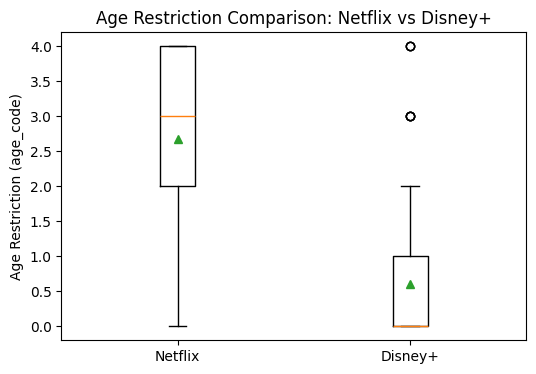

In [26]:
plt.figure(figsize=(6,4))
plt.boxplot([net_age, dis_age], labels=["Netflix", "Disney+"], showmeans=True)
plt.ylabel("Age Restriction (age_code)")
plt.title("Age Restriction Comparison: Netflix vs Disney+")
plt.show()

In [27]:
u_stat, p_val = stats.mannwhitneyu(
    net_age,
    dis_age,
    alternative='greater'   # Netflix > Disney+
)

print("Mann–Whitney U statistic:", u_stat)
print("p-value:", p_val)

Mann–Whitney U statistic: 1209699.5
p-value: 2.656927667628983e-212


In [28]:
alpha = 0.05

print("\n--- Conclusion ---")
if p_val < alpha:
    print("Reject H0: Netflix has significantly higher age restrictions than Disney+.")
else:
    print("Fail to reject H0: No evidence that Netflix has higher age restrictions than Disney+.")

if net_age.mean() > dis_age.mean():
    print("Observed difference: Netflix has higher average age rating.")
else:
    print("Observed difference: Disney+ has equal or higher age rating.")


--- Conclusion ---
Reject H0: Netflix has significantly higher age restrictions than Disney+.
Observed difference: Netflix has higher average age rating.


In [29]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, ttest_ind

df = pd.read_csv("/content/movies_cleaned.csv")

# ----------------------------
# Alternative 1: Unweighted Mean
# ----------------------------
net_mean = df[df["Netflix_flag"]==1]["rt_score"].mean()
dis_mean = df[df["Disney+_flag"]==1]["rt_score"].mean()

mean_result = "Disney+" if dis_mean > net_mean else "Netflix"

# ----------------------------
# Alternative 2: Chi-Square Test (Age Distribution)
# ----------------------------
table = pd.crosstab(df["age_code"], df["Disney+_flag"])
chi2, p_chi, _, _ = chi2_contingency(table)

chi_result = "Disney+" if p_chi < 0.05 else "No Difference"

# ----------------------------
# Alternative 3: Welch t-test
# ----------------------------
net_rt = df[df["Netflix_flag"]==1]["rt_score"].dropna()
dis_rt = df[df["Disney+_flag"]==1]["rt_score"].dropna()

t_stat, p_t = ttest_ind(net_rt, dis_rt, equal_var=False)

t_result = "Disney+" if (p_t < 0.05 and dis_mean > net_mean) else "No Difference"

# ----------------------------
# Print all results
# ----------------------------
print("\n--- Individual Method Results ---")
print("Unweighted Mean Winner:", mean_result)
print("Chi-Square Age Test:", chi_result)
print("Welch t-Test Winner:", t_result)

# ----------------------------
# IF–ELSE: Do all match?
# ----------------------------
methods = [mean_result, chi_result, t_result]

if methods.count("Disney+") == len(methods):
    print("\nAll three methods agree: Disney+ has better results.")
elif methods.count("Netflix") == len(methods):
    print("\nAll three methods agree: Netflix has better results.")
else:
    print("\nResults differ between methods — not all methods agree.")



--- Individual Method Results ---
Unweighted Mean Winner: Disney+
Chi-Square Age Test: Disney+
Welch t-Test Winner: Disney+

All three methods agree: Disney+ has better results.


In [30]:
df = pd.read_csv("/content/movies_cleaned.csv")
df.shape

(9515, 15)

In [31]:
# sklearn-based verification of earlier results
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import permutation_test_score
from sklearn.metrics import make_scorer, roc_auc_score, r2_score
from sklearn.utils import check_random_state

# ---- Load cleaned data ----
df = pd.read_csv("/content/movies_cleaned.csv")
print("Loaded:", df.shape)

# ---- Prepare Age vs Platform (Netflix) ----
# Keep rows with age_code and Netflix_flag
age_df = df[["age_code", "Netflix_flag"]].dropna(subset=["age_code", "Netflix_flag"]).copy()
X_age = age_df[["age_code"]].values.astype(float)   # predictor: age_code (ordinal)
y_net = age_df["Netflix_flag"].values.astype(int)   # target: 1 if on Netflix, else 0

print("\nAge sample sizes (Netflix_flag):", np.bincount(y_net.astype(int)))
print("Mean age_code (Netflix):", age_df[age_df["Netflix_flag"]==1]["age_code"].mean())
print("Mean age_code (non-Netflix):", age_df[age_df["Netflix_flag"]==0]["age_code"].mean())

# Fit logistic regression
log = LogisticRegression(solver="lbfgs", max_iter=1000)
log.fit(X_age, y_net)
coef_age = float(log.coef_[0,0])
intercept_age = float(log.intercept_[0])
print("\nLogisticRegression coef (age -> P(Netflix)):", coef_age)
print("Interpretation: positive coef -> higher age -> higher P(Netflix)")

# Permutation test for association (use ROC AUC as scoring to be robust to imbalance)
rng = check_random_state(0)
score_age, perm_scores_age, pvalue_age = permutation_test_score(
    log, X_age, y_net, scoring="roc_auc", n_permutations=1000, random_state=rng, n_jobs=-1
)
print(f"Permutation ROC-AUC score = {score_age:.4f}, permutation p-value = {pvalue_age:.4f}")

# ---- Prepare RT vs Platform (Netflix) ----
rt_df = df[["rt_score", "Netflix_flag"]].dropna(subset=["rt_score", "Netflix_flag"]).copy()
X_netflag = rt_df[["Netflix_flag"]].values.astype(float)   # 1 if Netflix, 0 otherwise
y_rt = rt_df["rt_score"].values.astype(float)

print("\nRT sample sizes:", len(y_rt))
print("Mean RT (Netflix):", rt_df[rt_df["Netflix_flag"]==1]["rt_score"].mean())
print("Mean RT (non-Netflix):", rt_df[rt_df["Netflix_flag"]==0]["rt_score"].mean())

# Fit linear regression: RT ~ Netflix_flag
lr = LinearRegression()
lr.fit(X_netflag, y_rt)
coef_rt = float(lr.coef_[0])    # approximate difference in means between Netflix (1) and non-Netflix (0)
intercept_rt = float(lr.intercept_)
print("\nLinearRegression coef (Netflix_flag -> RT):", coef_rt)
print("Interpretation: positive coef -> Netflix has higher RT on average; negative -> lower")

# Permutation test for regression (use R^2 scoring)
score_rt, perm_scores_rt, pvalue_rt = permutation_test_score(
    lr, X_netflag, y_rt, scoring="r2", n_permutations=1000, random_state=rng, n_jobs=-1
)
print(f"Permutation R^2 score = {score_rt:.4f}, permutation p-value = {pvalue_rt:.4f}")

# ---- Summarize decisions (simple if/else) ----
alpha = 0.05
print("\n--- Summary conclusions (sklearn + permutation tests) ---")

# Age conclusion
age_conclusion = "Netflix has higher age restrictions" if (coef_age > 0 and pvalue_age < alpha) else (
    "No evidence Netflix has higher age restrictions" if pvalue_age >= alpha else "Coefficient indicates Netflix lower")
print("Age test:", age_conclusion, f"(coef={coef_age:.4f}, p={pvalue_age:.4f})")

# RT conclusion
# coef_rt is (predicted RT for Netflix) - (predicted RT for non-Netflix)
rt_conclusion = "Netflix has higher RT scores" if (coef_rt > 0 and pvalue_rt < alpha) else (
    "No evidence Netflix has higher RT scores" if pvalue_rt >= alpha else "Coefficient indicates Netflix lower")
print("RT test:", rt_conclusion, f"(coef={coef_rt:.4f}, p={pvalue_rt:.4f})")

# Also show the direction of mean difference (unweighted) to compare with coef
mean_net = rt_df[rt_df["Netflix_flag"]==1]["rt_score"].mean()
mean_dis_or_other = rt_df[rt_df["Netflix_flag"]==0]["rt_score"].mean()
print("\nUnweighted mean RT difference (Netflix - others) = {:.3f} (Netflix mean {:.3f}, Others mean {:.3f})"
      .format(mean_net - mean_dis_or_other, mean_net, mean_dis_or_other))


Loaded: (9515, 15)

Age sample sizes (Netflix_flag): [3440 1898]
Mean age_code (Netflix): 2.682297154899895
Mean age_code (non-Netflix): 2.3043604651162792

LogisticRegression coef (age -> P(Netflix)): 0.16785104999771655
Interpretation: positive coef -> higher age -> higher P(Netflix)
Permutation ROC-AUC score = 0.5660, permutation p-value = 0.0010

RT sample sizes: 9508
Mean RT (Netflix): 54.447939262472886
Mean RT (non-Netflix): 52.972852233676974

LinearRegression coef (Netflix_flag -> RT): 1.4750870287959343
Interpretation: positive coef -> Netflix has higher RT on average; negative -> lower
Permutation R^2 score = -2.6973, permutation p-value = 1.0000

--- Summary conclusions (sklearn + permutation tests) ---
Age test: Netflix has higher age restrictions (coef=0.1679, p=0.0010)
RT test: No evidence Netflix has higher RT scores (coef=1.4751, p=1.0000)

Unweighted mean RT difference (Netflix - others) = 1.475 (Netflix mean 54.448, Others mean 52.973)
